<a href="https://colab.research.google.com/github/prakhar-pd15/delta-demo/blob/main/Lab6-Cats-v-Dogs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Training with a Larger Dataset - Cats and Dogs

In the previous lab you trained a classifier with a horses-v-humans dataset. You saw that despite getting great training results, when you tried to do classification with real images, there were many errors, due primarily to overfitting -- where the network  does very well with data that it has previously seen, but poorly with data it hasn't!

In this lab you'll look at a real, and very large dataset, and see the impact this has to avoid overfitting.

In [35]:
import os
import random
import tensorflow as tf
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from shutil import copyfile
import kagglehub

In [36]:
print("Downloading dataset from Kaggle...")
# Download the dataset using kagglehub
kaggle_dataset_path = kagglehub.dataset_download("karakaggle/kaggle-cat-vs-dog-dataset")
print(f"Dataset downloaded to: {kaggle_dataset_path}")

# kagglehub.dataset_download already extracts the dataset.
# The path returned is the root of the extracted dataset.
# Based on the typical structure of this dataset, images are in a subdirectory like 'kagglecatsanddogs_3367a/PetImages/'

base_image_dir = os.path.join(kaggle_dataset_path, 'kagglecatsanddogs_3367a', 'PetImages')


Using Colab cache for faster access to the 'kaggle-cat-vs-dog-dataset' dataset.
Dataset downloaded to: /kaggle/input/kaggle-cat-vs-dog-dataset


In [37]:
# Verify if the base_image_dir exists
if not os.path.exists(base_image_dir):
    print(f"Error: Expected image directory not found at {base_image_dir}")
    # Attempt to locate PetImages if the direct path is wrong
    found_petimages_path = None
    for root, dirs, files in os.walk(kaggle_dataset_path):
        if 'PetImages' in dirs:
            found_petimages_path = os.path.join(root, 'PetImages')
            break
    if found_petimages_path:
        base_image_dir = found_petimages_path
        print(f"Found PetImages at: {base_image_dir}")
    else:
        print("Could not locate 'PetImages' directory. Please inspect the dataset structure.")

CAT_SOURCE_DIR = os.path.join(base_image_dir, 'Cat')
DOG_SOURCE_DIR = os.path.join(base_image_dir, 'Dog')

In [38]:
# Print counts of files in the source directories to verify
if os.path.exists(CAT_SOURCE_DIR) and os.path.exists(DOG_SOURCE_DIR):
    print(len(os.listdir(CAT_SOURCE_DIR)))
    print(len(os.listdir(DOG_SOURCE_DIR)))
else:
    print(f"Error: Cat or Dog source directories not found. Cat: {CAT_SOURCE_DIR}, Dog: {DOG_SOURCE_DIR}")


# Expected Output:
# 12501
# 12501

12491
12470


In [39]:
try:
    os.mkdir('/tmp/cats-v-dogs')
    os.mkdir('/tmp/cats-v-dogs/training')
    os.mkdir('/tmp/cats-v-dogs/testing')
    os.mkdir('/tmp/cats-v-dogs/training/cats')
    os.mkdir('/tmp/cats-v-dogs/training/dogs')
    os.mkdir('/tmp/cats-v-dogs/testing/cats')
    os.mkdir('/tmp/cats-v-dogs/testing/dogs')
except OSError:
    pass

def split_data(SOURCE, TRAINING, TESTING, SPLIT_SIZE):
    files = []
    for filename in os.listdir(SOURCE):
        file = os.path.join(SOURCE, filename)
        if os.path.getsize(file) > 0:
            files.append(filename)
        else:
            print(filename + " is zero length, so ignoring.")

    training_length = int(len(files) * SPLIT_SIZE)
    testing_length = int(len(files) - training_length)
    shuffled_set = random.sample(files, len(files))
    training_set = shuffled_set[0:training_length]
    testing_set = shuffled_set[-testing_length:]

    for filename in training_set:
        this_file = os.path.join(SOURCE, filename)
        destination = os.path.join(TRAINING, filename)
        copyfile(this_file, destination)

    for filename in testing_set:
        this_file = os.path.join(SOURCE, filename)
        destination = os.path.join(TESTING, filename)
        copyfile(this_file, destination)



TRAINING_CATS_DIR = "/tmp/cats-v-dogs/training/cats/"
TESTING_CATS_DIR = "/tmp/cats-v-dogs/testing/cats/"
TRAINING_DOGS_DIR = "/tmp/cats-v-dogs/training/dogs/"
TESTING_DOGS_DIR = "/tmp/cats-v-dogs/testing/dogs/"

split_size = .9
split_data(CAT_SOURCE_DIR, TRAINING_CATS_DIR, TESTING_CATS_DIR, split_size)
split_data(DOG_SOURCE_DIR, TRAINING_DOGS_DIR, TESTING_DOGS_DIR, split_size)

# Expected output
# 666.jpg is zero length, so ignoring
# 11702.jpg is zero length, so ignoring

print(len(os.listdir('/tmp/cats-v-dogs/training/cats/')))
print(len(os.listdir('/tmp/cats-v-dogs/training/dogs/')))
print(len(os.listdir('/tmp/cats-v-dogs/testing/cats/')))
print(len(os.listdir('/tmp/cats-v-dogs/testing/dogs/')))

# Expected output:
# 11250
# 11250
# 1250
# 1250

12375
12348
2384
2372


In [40]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(16, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [41]:
model.compile(optimizer=RMSprop(learning_rate=0.001), loss='binary_crossentropy', metrics=['acc'])

In [42]:
TRAINING_DIR = "/tmp/cats-v-dogs/training/"
train_datagen = ImageDataGenerator(rescale=1.0/255.)
train_generator = train_datagen.flow_from_directory(TRAINING_DIR,
                                                    batch_size=250,
                                                    class_mode='binary',
                                                    target_size=(150, 150))

VALIDATION_DIR = "/tmp/cats-v-dogs/testing/"
validation_datagen = ImageDataGenerator(rescale=1.0/255.)
validation_generator = validation_datagen.flow_from_directory(VALIDATION_DIR,
                                                              batch_size=250,
                                                              class_mode='binary',
                                                              target_size=(150, 150))

# Expected Output:
# Found 22498 images belonging to 2 classes.
# Found 2500 images belonging to 2 classes.

Found 24721 images belonging to 2 classes.
Found 4756 images belonging to 2 classes.


In [43]:
# Note that this may take some time.
history = model.fit(train_generator, epochs=15, steps_per_epoch=90,
                    validation_data=validation_generator, validation_steps=6)

Epoch 1/15
59/90 ━━━━━━━━━━━━━━━━━━━━ 18s 601ms/step - acc: 0.5352 - loss: 0.7057

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


90/90 ━━━━━━━━━━━━━━━━━━━━ 67s 627ms/step - acc: 0.5747 - loss: 0.6812 - val_acc: 0.5380 - val_loss: 0.6873
Epoch 2/15
 9/90 ━━━━━━━━━━━━━━━━━━━━ 36s 446ms/step - acc: 0.5873 - loss: 0.6529

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


90/90 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - acc: 0.6009 - loss: 0.6526 - val_acc: 0.6807 - val_loss: 0.6176
Epoch 3/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 47s 524ms/step - acc: 0.6657 - loss: 0.6101 - val_acc: 0.7107 - val_loss: 0.5527
Epoch 4/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 6s 71ms/step - acc: 0.6631 - loss: 0.6220 - val_acc: 0.7307 - val_loss: 0.5508
Epoch 5/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 47s 517ms/step - acc: 0.7174 - loss: 0.5485 - val_acc: 0.7553 - val_loss: 0.5112
Epoch 6/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - acc: 0.7342 - loss: 0.5477 - val_acc: 0.6320 - val_loss: 0.6498
Epoch 7/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 46s 508ms/step - acc: 0.7475 - loss: 0.5101 - val_acc: 0.7760 - val_loss: 0.4646
Epoch 8/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step - acc: 0.7587 - loss: 0.4911 - val_acc: 0.7620 - val_loss: 0.4836
Epoch 9/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 46s 508ms/step - acc: 0.7758 - loss: 0.4701 - val_acc: 0.7040 - val_loss: 0.5859
Epoch 10/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - acc: 0.7782

<Figure size 640x480 with 0 Axes>

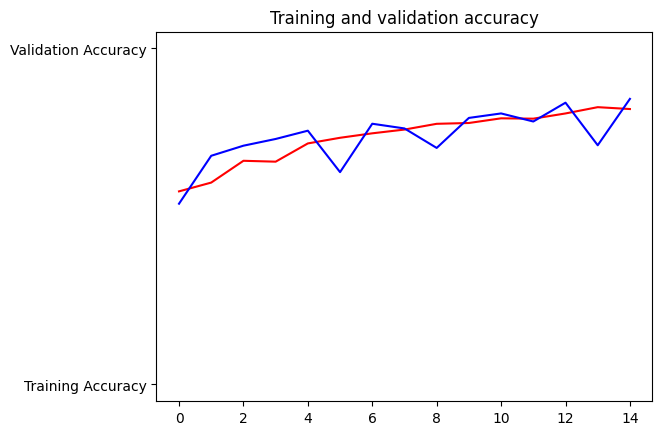

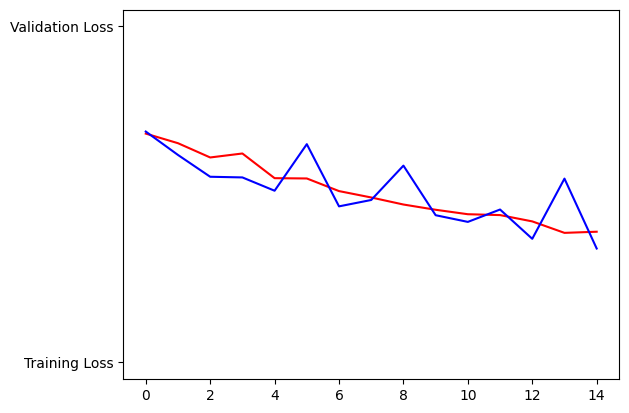

<Figure size 640x480 with 0 Axes>

In [44]:
%matplotlib inline

import matplotlib.image  as mpimg
import matplotlib.pyplot as plt

#-----------------------------------------------------------
# Retrieve a list of list results on training and test data
# sets for each training epoch
#-----------------------------------------------------------
acc=history.history['acc']
val_acc=history.history['val_acc']
loss=history.history['loss']
val_loss=history.history['val_loss']

epochs=range(len(acc)) # Get number of epochs

#------------------------------------------------
# Plot training and validation accuracy per epoch
#------------------------------------------------
plt.plot(epochs, acc, 'r', "Training Accuracy")
plt.plot(epochs, val_acc, 'b', "Validation Accuracy")
plt.title('Training and validation accuracy')
plt.figure()

#------------------------------------------------
# Plot training and validation loss per epoch
#------------------------------------------------
plt.plot(epochs, loss, 'r', "Training Loss")
plt.plot(epochs, val_loss, 'b', "Validation Loss")
plt.figure()


# Desired output. Charts with training and validation metrics. No crash :)

In [52]:
import numpy as np
from google.colab import files
from keras.preprocessing import image

uploaded = files.upload()

for fn in uploaded.keys():

  # predicting images
  path = '/content/' + fn
  img = image.load_img(path, target_size=(150, 150))
  x = image.img_to_array(img)
  x = np.expand_dims(x, axis=0)
  # Rescale the image like during training
  x = x / 255.0

  images = np.vstack([x])
  classes = model.predict(images, batch_size=10)
  print(classes[0])
  if classes[0]>0.5:
    print(fn + " is a dog")
  else:
    print(fn + " is a cat")

Saving catt.jpg to catt (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
[0.35551035]
catt (1).jpg is a cat
